# Task 6: House Price Prediction

## Problem Statement

The objective of this project is to predict house sale prices using various property features such as living area, number of bedrooms, bathrooms, year built, garage capacity, and basement size.

This is a regression problem where machine learning is used to estimate the selling price of a house based on its characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   i

In [5]:
print("Missing Values")

df.isnull().sum().sort_values(ascending=False).head(20)

Missing Values


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [9]:
features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "YearBuilt",
    "OverallQual",
    "GarageCars",
    "TotalBsmtSF"
]

target = "SalePrice"

df_model = df[features + [target]].copy()

df_model.fillna(df_model.median(numeric_only=True), inplace=True)

print("Remaining Missing Values")

print(df_model.isnull().sum())

Remaining Missing Values
GrLivArea       0
BedroomAbvGr    0
FullBath        0
YearBuilt       0
OverallQual     0
GarageCars      0
TotalBsmtSF     0
SalePrice       0
dtype: int64


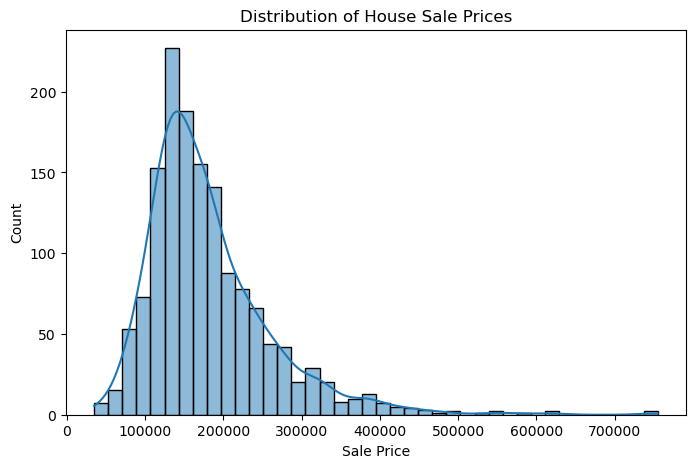

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df_model["SalePrice"], bins=40, kde=True)

plt.title("Distribution of House Sale Prices")

plt.xlabel("Sale Price")

plt.ylabel("Count")

plt.show()

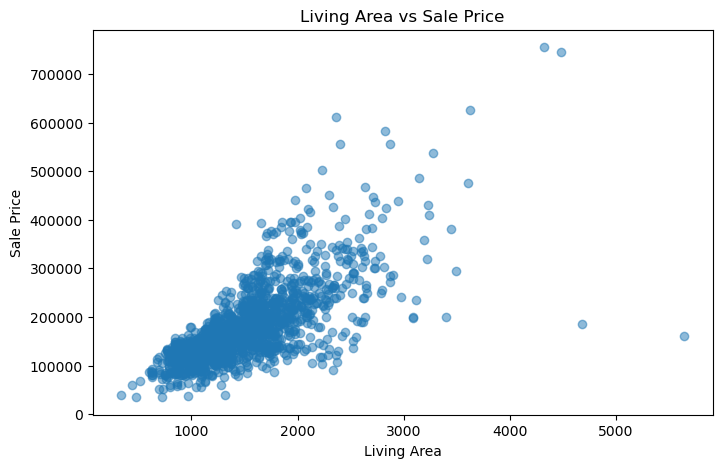

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_model["GrLivArea"],
    df_model["SalePrice"],
    alpha=0.5
)

plt.title("Living Area vs Sale Price")

plt.xlabel("Living Area")

plt.ylabel("Sale Price")

plt.show()

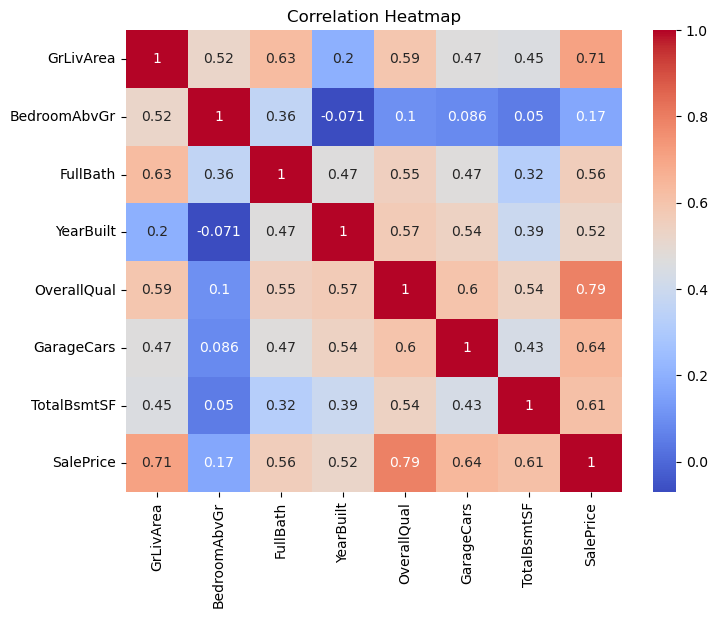

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_model.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
X = df_model[features]

y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

print("Training Samples:", len(X_train))

print("Testing Samples:", len(X_test))

Training Samples: 1168
Testing Samples: 292


In [15]:
model = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.1,

    max_depth=4,

    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [16]:
y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,2))

print("Root Mean Squared Error :", round(rmse,2))

print("R² Score :", round(r2,4))

Mean Absolute Error : 19139.47
Root Mean Squared Error : 28810.18
R² Score : 0.8918


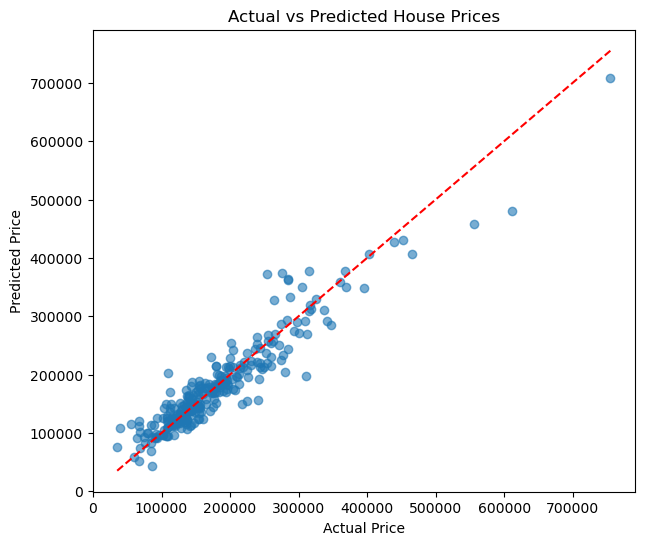

In [18]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    "r--"
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.show()

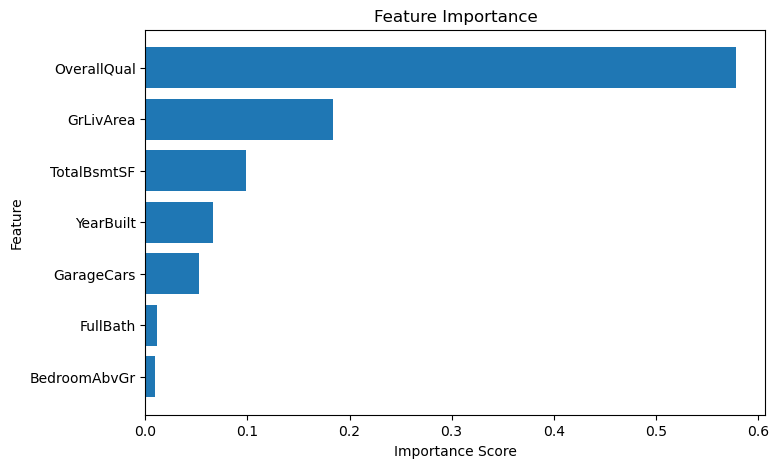

In [19]:
importance = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance"

)

plt.figure(figsize=(8,5))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

## Results

The Gradient Boosting Regressor was trained to predict house sale prices using seven important housing features.

The model achieved a good R² score, indicating that it successfully captured the relationship between the selected features and house prices.

The Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) show the average prediction error.

The feature importance chart indicates that **OverallQual** and **GrLivArea** have the greatest influence on predicting house prices, which agrees with the expected outcome mentioned in the task description.